## Task Overview

The focus of this first task is on the process of loading and preparing image data to be fed to a neural network. This is the first step in developing a modeling pipeline.

**After completing this task, you will know how to load, manage, and visualize image data in PyTorch.**

In this task, you will practice loading the [MNIST](https://en.wikipedia.org/wiki/MNIST_database) dataset [contained within PyTorch](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) using PyTorch utilities. MNIST is a good first image dataset for learning models and for getting familiar with using packaged datasets.

You will set up the data so that it is:

- Actively loaded;
- Augmented on-the-fly;
- Split into training / validation / test partitions;
- Normalized inside the dataloader.

You will then visualize a single digit from the dataset.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise indicated.

### Static code 1

In [ ]:
# @title Mount drive and run imports
from google.colab import drive
drive.mount("/content/gdrive")

In [ ]:
# @title Importing Necessary Packages

# import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import numbers
import torch

import pandas as pd
import os

from pathlib import Path

from torch.utils.data import Dataset, DataLoader
import rasterio

# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

In [ ]:
# @title Save path

# Modify 'save_dir' to the path to download MNIST dataset.
save_dir = "your_directory"

### Task 1
#### **Load, transform, and normalize MNIST data (Steps 1.1-1.4)**

In this task, you will develop functions that will:

1) Apply some additional processing steps to the imagery, including two image transformations (random rotation of images and randomly cropping images), conversion of images to tensors, and normalizing the imagery.

2) Load in the built-in MNIST datasets using functions that apply those image processing steps, making separate loaders for three splits: 1) train, 2) validation, and 3) test.

3) Make each of the three data loaders iterable;

4) Visualize a single digit from the dataset

Useful documentation you should read before coding:

[torchvision transforms documentation](https://pytorch.org/vision/stable/transforms.html)

Pay special attention to:

- `v2.Compose`
- `v2.RandomRotation` (use 5 degrees and a fill of 0)
- `v2.RandomCrop` (use a size of 28, and padding of 2)
- `v2.ToImage()` and `v2.ToDtype()`
- `v2.Normalize` (apply the mean and standard deviation provided above)

Note: We imported `transforms` V2, which is why the functions are pulled from the `v2` sub-module.  

Note: These values represent the mean and standard deviation of the MNIST dataset, which you will need for normalizing the data:

mnist_mean = 0.13066048920154572
mnist_std = 0.30810779333114624

#### Step 1: Define processing pipeline

Use `v2.Compose` to develop a function that applies in the following order: `v2.RandomRotation`, `v2.RandomCrop`, `v2.ToImage()` followed by v2.ToDtype(torch.float32, scale=True), then `transforms.Normalize`.

These functions will do the necessary preprocessings on train and test datasets. Name the functions `train_transforms`, and `test_transforms`.

You will only apply the rotation and crop within `train_transforms`. `test_transforms` only needs the image conversions type conversions and normalization.


In [ ]:
## Answer here

#### Step 2: Load in the MNIST data and apply transforms

Using `datasets.MNIST`, `data.random_split`, and a ratio of 90% to split the train set into `train` and `validation` (you should know what's the differences between test and validation data--if not, please ask).

First, you are going to `datasets.MNIST` to create `train_data` and `test_data` objects, in which you use the transform argument to pass in your different transform function to each dataset. Choose to download the data, and the train argument will specify which MNIST data pool (train or test) the data is drawn from.  

Second, you will then split the train dataset into train and validation sets. Use length of the `train_data` object and the split ratio (0.9) to determine how many samples are for train (90% of total) and how many for validate (10%) of total.

You will then apply `data.random_split` to `train_data` to pull out an updated `train_data` split, and then new `validate_data` split. Because validation data should not have transformations applied to them (rotate, crop), you will overwrite the transformation on the `validation.data.transform` with the `test_transform` function.

To do this, first **note** that `random_split` does not create independent datasets. It creates subsets that share the same underlying dataset object. Because of this, if you change the transform of the validation subset without making a copy, the training subset will also be affected.

Using `copy.deepcopy` ensures that the validation data can use different transforms (no augmentation) without altering the training data. So make a deep copy of `validate_data` first before over-writing the transformation.

In [ ]:
## Answer here

Check: After you have made the three datasets, you should get the following results from these functions:



In [ ]:
print("train transform:", train_data.dataset.transform);
print("valid transform:",validate_data.dataset.transform);
print("test transform:",test_data.transform)

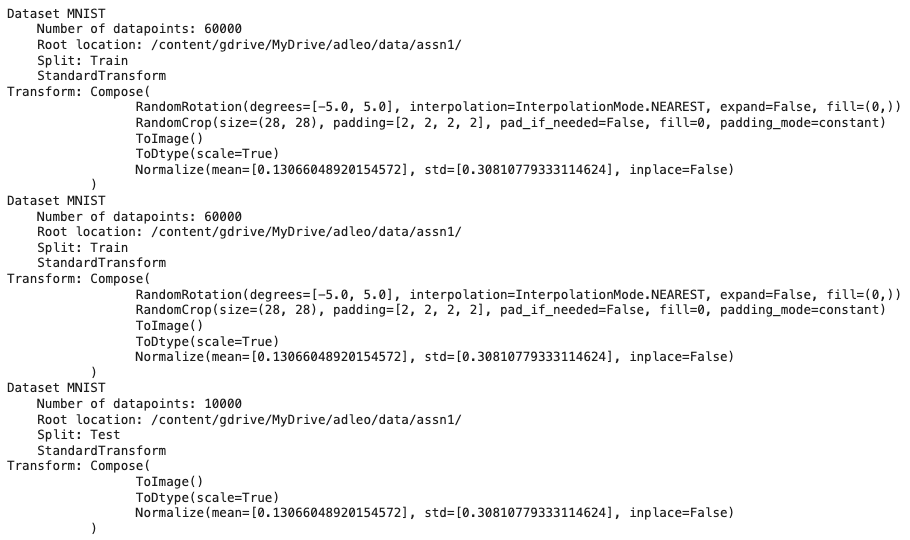

#### Step 3: Make data loaders

Use `data.DataLoader` to make an iterable `train_loader`, `validation_loader`, and `test_loader`.

We want to make a batch size of 50, and apply shuffle to the `train_loader`but not `validation_loader` and `test_loader`

Note: when doing this, use the function `set_seed(1)` when doing so, placed before the code that sets up your loaders, e.g.    

```python
set_seed(1)
# the code you are running starts here
```
This allows us to all get the same results, and helps you know whether your code is performing as it should.

In [ ]:
## Answer here

Check: You should see the results below when running the following code.

In [ ]:
print(test_loader.dataset.data[0][5:10, 5:10])
print(train_loader.dataset.dataset.data[0][5:10, 5:10])
print(validate_loader.dataset.dataset.data[0][5:10, 5:10])

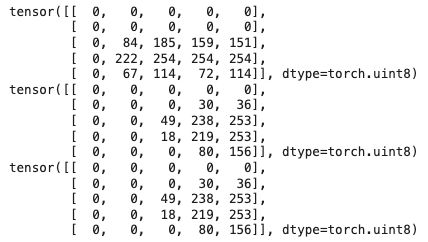

#### Step 4: Visualize one of the images

Use matplotlib.pyplot to visualize the "second" item in the batch of image and corresponding label (e.g., `idx = 1`).

You are going to use `iter` and `next` to extract the images and labels from batch of the `train_loader`.

Use the correct index for getting the second image and label out of the batch. Note the image will have to be `squeeze`d to strip out its channel dimension. The label is just a number.

When plotting use a gray scale cmap. The label value can be placed as a title on top of the plot.

In [ ]:
## Answer here

Check: you should see the following image when you display the extracted image.

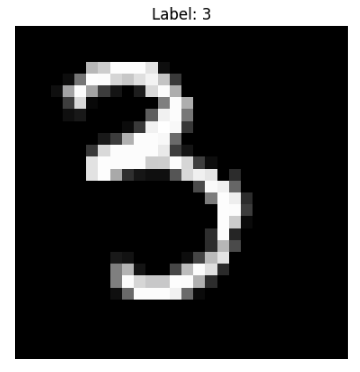